In [2]:
import tensorflow as tf

In [4]:
mnist = tf.keras.datasets.mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()
print(x_train.min(), x_train.max())
print(x_train.shape)
print(x_test.shape)
print(x_train[0])

11490434/11490434 [==============================] - 7s 1us/step
0 255
(60000, 28, 28)
(10000, 28, 28)
[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136
  175  26 166 255 247 127   0   0   0   0]
 [  0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253
  225 172 253 242 195  64   0   0   0   0]
 [  0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251
   9

In [5]:
x_train, x_test = x_train / 255.0, x_test / 255.0
print(x_train[0])

[[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.    

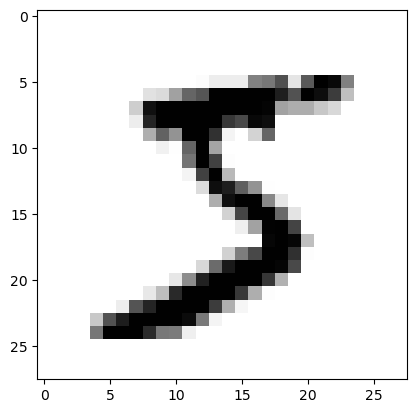

In [6]:
import matplotlib.pyplot as plt
plt.imshow(x_train[0], cmap=plt.cm.binary)
plt.show()

In [7]:
print(y_train.shape)
print(y_train[0])

(60000,)
5


In [8]:
model = tf.keras.models.Sequential ([
tf.keras.layers. Flatten(input_shape=(28, 28)),
tf.keras.layers. Dense (128, activation= 'relu'), 
tf.keras.layers. Dropout (0.2),
tf.keras.layers. Dense (10)
])

In [10]:
import copy #needed for copy or deepcopy 
x_train_copy = copy.copy(x_train)
print (x_train_copy.shape)
print (x_train_copy[0].flatten().shape)
x_train_copy = x_train_copy.reshape(60000, 28*28)
print (x_train_copy.shape)
print (x_train.shape)

(60000, 28, 28)
(784,)
(60000, 784)
(60000, 28, 28)


In [12]:
#reshape train and test data
x_train = x_train.reshape(60000, 28*28)
x_test = x_test.reshape(10000, 28*28)

In [41]:
#print(x_train[:1])

In [34]:
predictions = model(x_train[:1])
print(predictions)
predictions = predictions.numpy()
predictions

tf.Tensor(
[[ 0.19696535  0.0515246   0.62015575 -0.17264915  0.15448701  0.18041684
   0.4171219   0.22558358  0.3493023  -0.232738  ]], shape=(1, 10), dtype=float32)


array([[ 0.19696535,  0.0515246 ,  0.62015575, -0.17264915,  0.15448701,
         0.18041684,  0.4171219 ,  0.22558358,  0.3493023 , -0.232738  ]],
      dtype=float32)

In [35]:
tf.nn.softmax(predictions).numpy()

array([[0.09886285, 0.08548088, 0.15094626, 0.06831429, 0.09475127,
        0.09724027, 0.12320998, 0.101733  , 0.11513098, 0.06433026]],
      dtype=float32)

In [36]:
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

In [37]:
loss_fn(y_train[:1], predictions).numpy()

2.3305705

In [46]:
#MODEL ONE

model_relu_adam = tf.keras.models.Sequential ([
#tf.keras.layers. Flatten(input_shape=(28, 28)),
tf.keras.layers. Dense (16, activation= 'relu', input_shape=(784,)), 
tf.keras.layers. Dense (10, activation= 'relu'),
tf.keras.layers. Dropout (0.2),
tf.keras.layers. Dense (10)
])

In [47]:
#MODEL TWO

model_relu_sgd = tf.keras.models.Sequential ([
#tf.keras.layers. Flatten(input_shape=(28, 28)),
tf.keras.layers. Dense (16, activation= 'relu', input_shape=(784,)), 
tf.keras.layers. Dense (10, activation= 'relu'),
tf.keras.layers. Dropout (0.2),
tf.keras.layers. Dense (10)
])

In [48]:
#MODEL THREE

model_relu_rmsprop = tf.keras.models.Sequential ([
#tf.keras.layers. Flatten(input_shape=(28, 28)),
tf.keras.layers. Dense (16, activation= 'relu', input_shape=(784,)), 
tf.keras.layers. Dense (10, activation= 'relu'),
tf.keras.layers. Dropout (0.2),
tf.keras.layers. Dense (10)
])

In [49]:
#MODEL FOUR

model_tanh_adam = tf.keras.models.Sequential ([
#tf.keras.layers. Flatten(input_shape=(28, 28)),
tf.keras.layers. Dense (16, activation= 'tanh', input_shape=(784,)), 
tf.keras.layers. Dense (10, activation= 'tanh'),
tf.keras.layers. Dropout (0.2),
tf.keras.layers. Dense (10)
])

In [50]:
#MODEL FIVE

model_tanh_sgd = tf.keras.models.Sequential ([
#tf.keras.layers. Flatten(input_shape=(28, 28)),
tf.keras.layers. Dense (16, activation= 'tanh', input_shape=(784,)), 
tf.keras.layers. Dense (10, activation= 'tanh'),
tf.keras.layers. Dropout (0.2),
tf.keras.layers. Dense (10)
])

In [51]:
#MODEL SIX

model_tanh_rmsprop = tf.keras.models.Sequential ([
#tf.keras.layers. Flatten(input_shape=(28, 28)),
tf.keras.layers. Dense (16, activation= 'tanh', input_shape=(784,)), 
tf.keras.layers. Dense (10, activation= 'tanh'),
tf.keras.layers. Dropout (0.2),
tf.keras.layers. Dense (10)
])

In [52]:
#MODEL ONE

model_relu_adam.compile(optimizer='adam',
             loss=loss_fn,
             metrics = ['accuracy'])

In [53]:
#MODEL TWO

model_relu_sgd.compile(optimizer='sgd',
             loss=loss_fn,
             metrics = ['accuracy'])

In [54]:
#MODEL THREE

model_relu_rmsprop.compile(optimizer='rmsprop',
             loss=loss_fn,
             metrics = ['accuracy'])

In [55]:
#MODEL FOUR

model_tanh_adam.compile(optimizer='adam',
             loss=loss_fn,
             metrics = ['accuracy'])

In [56]:
#MODEL FIVE

model_tanh_sgd.compile(optimizer='sgd',
             loss=loss_fn,
             metrics = ['accuracy'])

In [57]:
#MODEL SIX

model_tanh_rmsprop.compile(optimizer='rmsprop',
             loss=loss_fn,
             metrics = ['accuracy'])

In [58]:
#MODEL ONE

model_relu_adam.fit(x_train, y_train, epochs=5)

Epoch 1/5
1875/1875 [==============================] - 2s 917us/step - loss: 0.7797 - accuracy: 0.7396
Epoch 2/5
1875/1875 [==============================] - 2s 842us/step - loss: 0.4820 - accuracy: 0.8428
Epoch 3/5
1875/1875 [==============================] - 2s 932us/step - loss: 0.4293 - accuracy: 0.8575
Epoch 4/5
1875/1875 [==============================] - 2s 888us/step - loss: 0.3967 - accuracy: 0.8710
Epoch 5/5
1875/1875 [==============================] - 2s 887us/step - loss: 0.3704 - accuracy: 0.8832


In [59]:
#MODEL TWO

model_relu_sgd.fit(x_train, y_train, epochs=5)

Epoch 1/5
1875/1875 [==============================] - 2s 889us/step - loss: 1.2622 - accuracy: 0.5750
Epoch 2/5
1875/1875 [==============================] - 2s 834us/step - loss: 0.7734 - accuracy: 0.7501
Epoch 3/5
1875/1875 [==============================] - 2s 836us/step - loss: 0.6681 - accuracy: 0.7876
Epoch 4/5
1875/1875 [==============================] - 2s 844us/step - loss: 0.6036 - accuracy: 0.8090
Epoch 5/5
1875/1875 [==============================] - 2s 837us/step - loss: 0.5563 - accuracy: 0.8249


In [60]:
#MODEL THREE

model_relu_rmsprop.fit(x_train, y_train, epochs=5)

Epoch 1/5
1875/1875 [==============================] - 2s 942us/step - loss: 0.8354 - accuracy: 0.7288
Epoch 2/5
1875/1875 [==============================] - 2s 832us/step - loss: 0.5246 - accuracy: 0.8327
Epoch 3/5
1875/1875 [==============================] - 2s 860us/step - loss: 0.4677 - accuracy: 0.8544
Epoch 4/5
1875/1875 [==============================] - 2s 810us/step - loss: 0.4369 - accuracy: 0.8650
Epoch 5/5
1875/1875 [==============================] - 2s 817us/step - loss: 0.4130 - accuracy: 0.8738


In [61]:
#MODEL FOUR

model_tanh_adam.fit(x_train, y_train, epochs=5)

Epoch 1/5
1875/1875 [==============================] - 2s 864us/step - loss: 0.6545 - accuracy: 0.8298
Epoch 2/5
1875/1875 [==============================] - 2s 975us/step - loss: 0.3568 - accuracy: 0.9014
Epoch 3/5
1875/1875 [==============================] - 2s 986us/step - loss: 0.3058 - accuracy: 0.9152
Epoch 4/5
1875/1875 [==============================] - 2s 877us/step - loss: 0.2808 - accuracy: 0.9199
Epoch 5/5
1875/1875 [==============================] - 2s 878us/step - loss: 0.2650 - accuracy: 0.9254


In [62]:
#MODEL FIVE

model_tanh_sgd.fit(x_train, y_train, epochs=5)

Epoch 1/5
1875/1875 [==============================] - 2s 843us/step - loss: 1.1627 - accuracy: 0.6869
Epoch 2/5
1875/1875 [==============================] - 2s 873us/step - loss: 0.6159 - accuracy: 0.8440
Epoch 3/5
1875/1875 [==============================] - 2s 864us/step - loss: 0.4909 - accuracy: 0.8702
Epoch 4/5
1875/1875 [==============================] - 2s 863us/step - loss: 0.4402 - accuracy: 0.8820
Epoch 5/5
1875/1875 [==============================] - 2s 829us/step - loss: 0.4001 - accuracy: 0.8912


In [63]:
#MODEL SIX

model_relu_rmsprop.fit(x_train, y_train, epochs=5)

Epoch 1/5
1875/1875 [==============================] - 2s 884us/step - loss: 0.4016 - accuracy: 0.8778
Epoch 2/5
1875/1875 [==============================] - 2s 824us/step - loss: 0.3946 - accuracy: 0.8790
Epoch 3/5
1875/1875 [==============================] - 2s 853us/step - loss: 0.3846 - accuracy: 0.8826
Epoch 4/5
1875/1875 [==============================] - 2s 825us/step - loss: 0.3809 - accuracy: 0.8851
Epoch 5/5
1875/1875 [==============================] - 2s 821us/step - loss: 0.3795 - accuracy: 0.8876


In [64]:
print("Model running Relu and Adam")
model_relu_adam.evaluate(x_test, y_test, verbose=2)

Model running Relu and Adam
313/313 - 0s - loss: 0.1995 - accuracy: 0.9432 - 277ms/epoch - 885us/step


[0.1995357871055603, 0.9431999921798706]

In [65]:
print("Model running Relu and sgd")
model_relu_sgd.evaluate(x_test, y_test, verbose=2)

Model running Relu and sgd
313/313 - 0s - loss: 0.3188 - accuracy: 0.9114 - 295ms/epoch - 944us/step


[0.31882959604263306, 0.9114000201225281]

In [66]:
print("Model running Relu and rmsprop")
model_relu_rmsprop.evaluate(x_test, y_test, verbose=2)

Model running Relu and rmsprop
313/313 - 0s - loss: 0.2548 - accuracy: 0.9367 - 299ms/epoch - 954us/step


[0.2547820210456848, 0.9366999864578247]

In [67]:
print("Model running tanh and Adam")
model_relu_rmsprop.evaluate(x_test, y_test, verbose=2)

Model running tanh and Adam
313/313 - 0s - loss: 0.2548 - accuracy: 0.9367 - 215ms/epoch - 687us/step


[0.2547820210456848, 0.9366999864578247]

In [68]:
print("Model running tanh and sgd")
model_relu_rmsprop.evaluate(x_test, y_test, verbose=2)

Model running tanh and sgd
313/313 - 0s - loss: 0.2548 - accuracy: 0.9367 - 214ms/epoch - 682us/step


[0.2547820210456848, 0.9366999864578247]

In [69]:
print("Model running tanh and rmsprop")
model_relu_rmsprop.evaluate(x_test, y_test, verbose=2)

Model running tanh and rmsprop
313/313 - 0s - loss: 0.2548 - accuracy: 0.9367 - 219ms/epoch - 700us/step


[0.2547820210456848, 0.9366999864578247]

#5 I decided to run all possibel permutations and list them above the one
the one with the highest accuracy was the Model running Relu and Adam You can see the results of all the models above.